In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pathlib
import sys

# ── Navigate to project root (notebook lives at notebooks/signals/) ───────────
_root = pathlib.Path.cwd()
for _ in range(4):                          # walk up at most 4 levels
    if (_root / 'src').is_dir() and (_root / 'data').is_dir():
        break
    _root = _root.parent
os.chdir(_root)
sys.path.insert(0, str(_root))
print(f"Working directory : {pathlib.Path.cwd()}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from dotenv import load_dotenv
load_dotenv()

from src.db.client import db
db.open()

%matplotlib inline
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
sns.set_style('whitegrid')
print('Setup complete.')


Working directory : /Users/rhlbh/projects/claudeProjects/quant


2026-04-11 17:17:28 [INFO] Opening DuckDB at data/quant.db


2026-04-11 17:17:28 [INFO] DB schema up to date (version 7)


Setup complete.


T10Y2Y  — 1976-06-01 to 2026-04-10
Count   : 12,461

Stats:
count    12461.000
mean         0.849
std          0.916
min         -2.410
25%          0.190
50%          0.790
75%          1.480
max          2.910


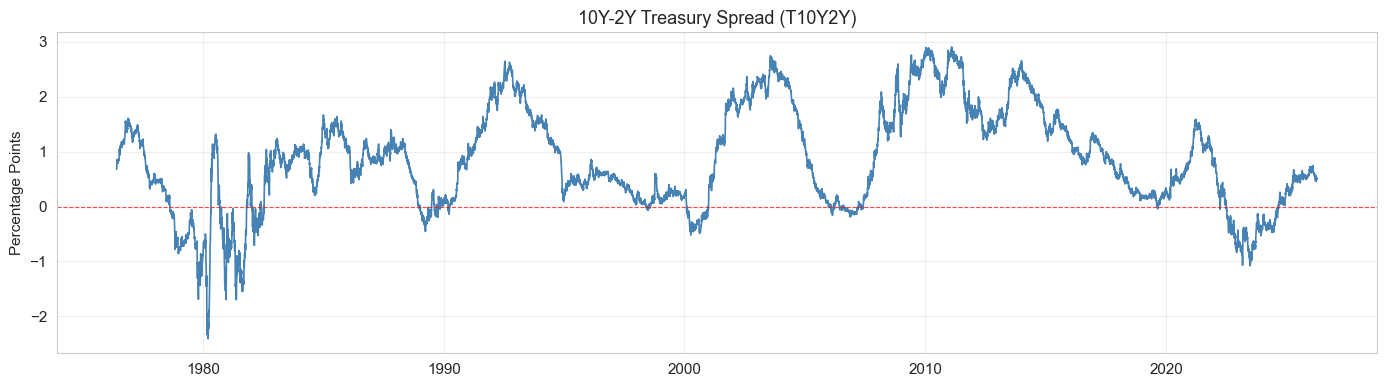

In [2]:
rows = db.query("""
    SELECT mo.period_date, mo.value
    FROM macro_observations mo
    JOIN macro_series ms ON mo.series_id = ms.id
    WHERE ms.code = 'T10Y2Y'
      AND mo.is_final = True
    ORDER BY mo.period_date
""")

spread_10y2y = pd.Series(
    {r['period_date']: r['value'] for r in rows},
    name='T10Y2Y',
)
spread_10y2y.index = pd.to_datetime(spread_10y2y.index)

print(f"T10Y2Y  — {spread_10y2y.index[0].date()} to {spread_10y2y.index[-1].date()}")
print(f"Count   : {len(spread_10y2y):,}")
print(f"\nStats:")
print(spread_10y2y.describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(spread_10y2y.index, spread_10y2y.values, lw=1.2, color='steelblue')
ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.7)
ax.set_title('10Y-2Y Treasury Spread (T10Y2Y)', fontsize=13)
ax.set_ylabel('Percentage Points')
plt.tight_layout()
plt.show()

Macro DataFrame shape : (16277, 4)
Date range            : 1962-01-02 → 2026-04-09

Null counts:
DGS2         3817
DGS10         225
VIXCLS       7116
DTWEXBGS    11070


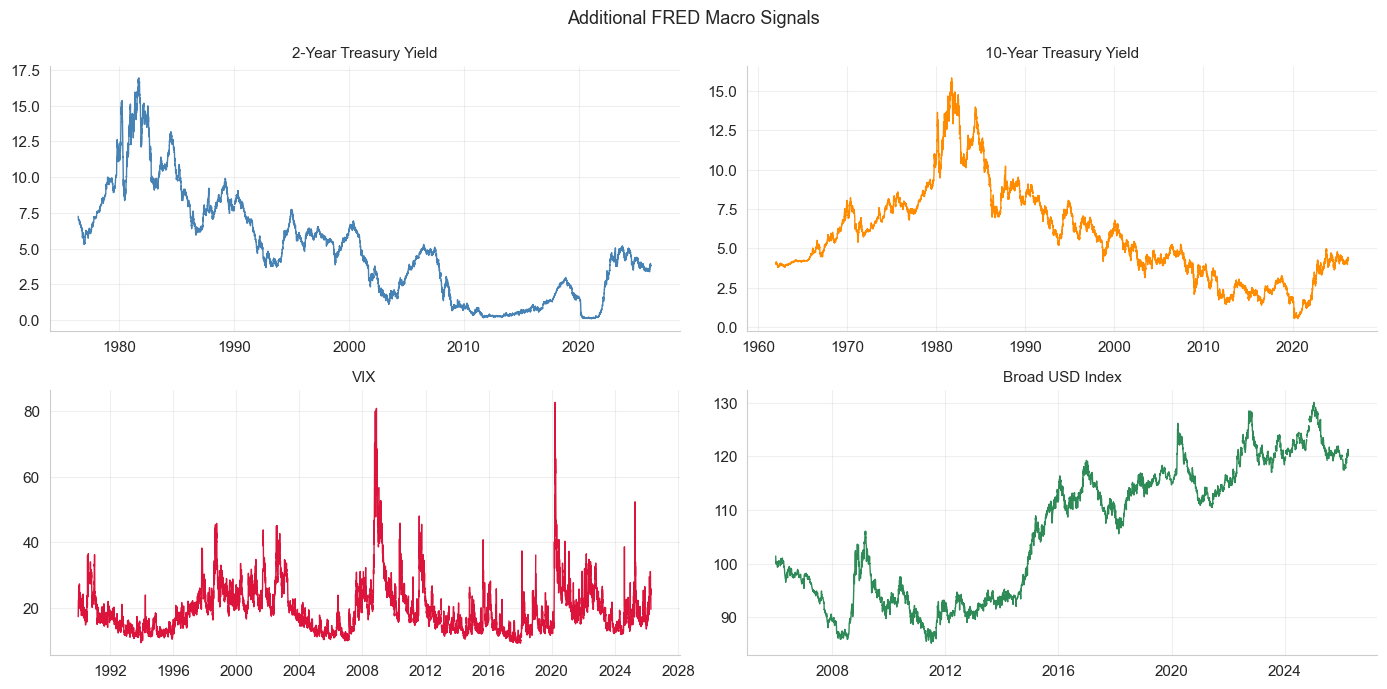

In [3]:
def load_fred(code):
    rows = db.query(
        """
        SELECT mo.period_date, mo.value
        FROM macro_observations mo
        JOIN macro_series ms ON mo.series_id = ms.id
        WHERE ms.code = ?
          AND mo.is_final = True
        ORDER BY mo.period_date
        """,
        [code],
    )
    s = pd.Series({r['period_date']: r['value'] for r in rows}, name=code)
    s.index = pd.to_datetime(s.index)
    return s

dgs2   = load_fred('DGS2')
dgs10  = load_fred('DGS10')
vix    = load_fred('VIXCLS')
dollar = load_fred('DTWEXBGS')

macro_df = pd.DataFrame({'DGS2': dgs2, 'DGS10': dgs10, 'VIXCLS': vix, 'DTWEXBGS': dollar})
print(f"Macro DataFrame shape : {macro_df.shape}")
print(f"Date range            : {macro_df.index[0].date()} → {macro_df.index[-1].date()}")
print(f"\nNull counts:\n{macro_df.isnull().sum().to_string()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
titles = {'DGS2': '2-Year Treasury Yield', 'DGS10': '10-Year Treasury Yield',
          'VIXCLS': 'VIX', 'DTWEXBGS': 'Broad USD Index'}
colors = ['steelblue', 'darkorange', 'crimson', 'seagreen']
for ax, (col, title), color in zip(axes.flat, titles.items(), colors):
    ax.plot(macro_df.index, macro_df[col], lw=1, color=color)
    ax.set_title(title, fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
plt.suptitle('Additional FRED Macro Signals', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# NOTE: Equity ETFs (SPY, XLF, XLE, XLK) are not in this database.
# Using the available FX cross-section instead.

FX_TICKERS = ['EURUSD', 'USDJPY', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'USDCAD']

rows = db.query(
    f"""
    SELECT a.ticker,
           CAST(p.timestamp AS DATE) AS date,
           p.close
    FROM prices p
    JOIN assets a ON p.asset_id = a.id
    WHERE a.ticker IN ({','.join(f"'{t}'" for t in FX_TICKERS)})
      AND p.interval = '1d'
    ORDER BY a.ticker, date
    """
)

fx_raw = pd.DataFrame(rows)
fx_raw['date'] = pd.to_datetime(fx_raw['date'])
prices_df = fx_raw.pivot(index='date', columns='ticker', values='close').sort_index()
prices_df = prices_df.reindex(columns=FX_TICKERS)

# Restrict to T10Y2Y history (starts 1976-06-01)
prices_df = prices_df[prices_df.index >= '1976-06-01']

# Daily log returns
log_returns_df = np.log(prices_df / prices_df.shift(1))

print(f"FX Prices shape : {prices_df.shape}")
print(f"Date range      : {prices_df.index[0].date()} → {prices_df.index[-1].date()}")
print(f"\nNull counts per ticker:")
print(prices_df.isnull().sum().to_string())
print(f"\nSample (last 3 rows):")
print(prices_df.tail(3).to_string())

FX Prices shape : (13019, 6)
Date range      : 1976-06-01 → 2026-03-25

Null counts per ticker:
ticker
EURUSD    182
USDJPY    124
GBPUSD    172
AUDUSD     38
NZDUSD    148
USDCAD    141

Sample (last 3 rows):
ticker       EURUSD     USDJPY   GBPUSD   AUDUSD   NZDUSD   USDCAD
date                                                              
2026-03-23  1.16148  158.39381  1.34328  0.70120  0.58657  1.37225
2026-03-24  1.15855  158.98917  1.33824  0.69684  0.58191  1.37638
2026-03-25  1.15625  159.47871  1.33658  0.69483  0.58074  1.38152


In [5]:
# Forward-fill macro data to the FX trading day calendar
spread_ffill = spread_10y2y.reindex(prices_df.index, method='ffill')
macro_ffill  = macro_df.reindex(prices_df.index, method='ffill')

# Common index: both spread and FX prices are non-null
has_spread = spread_ffill.notna()
has_prices = prices_df.notna().any(axis=1)
common_idx = prices_df.index[has_spread & has_prices]

spread_aligned = spread_ffill.loc[common_idx]
macro_aligned  = macro_ffill.loc[common_idx]
prices_aligned = prices_df.loc[common_idx]
returns_df     = log_returns_df.loc[common_idx]

print(f"Common trading days : {len(common_idx):,}")
print(f"Date range          : {common_idx[0].date()} → {common_idx[-1].date()}")
print(f"\nReturns — null counts:")
print(returns_df.isnull().sum().to_string())
print(f"\nSpread — null count: {spread_aligned.isnull().sum()}")

Common trading days : 13,019
Date range          : 1976-06-01 → 2026-03-25

Returns — null counts:
ticker
EURUSD    348
USDJPY    248
GBPUSD    338
AUDUSD     74
NZDUSD    289
USDCAD    279

Spread — null count: 0


Signals shape: (13019, 5)
NaN counts:
level                0
zscore             125
momentum            63
momentum_zscore    188
percentile         251


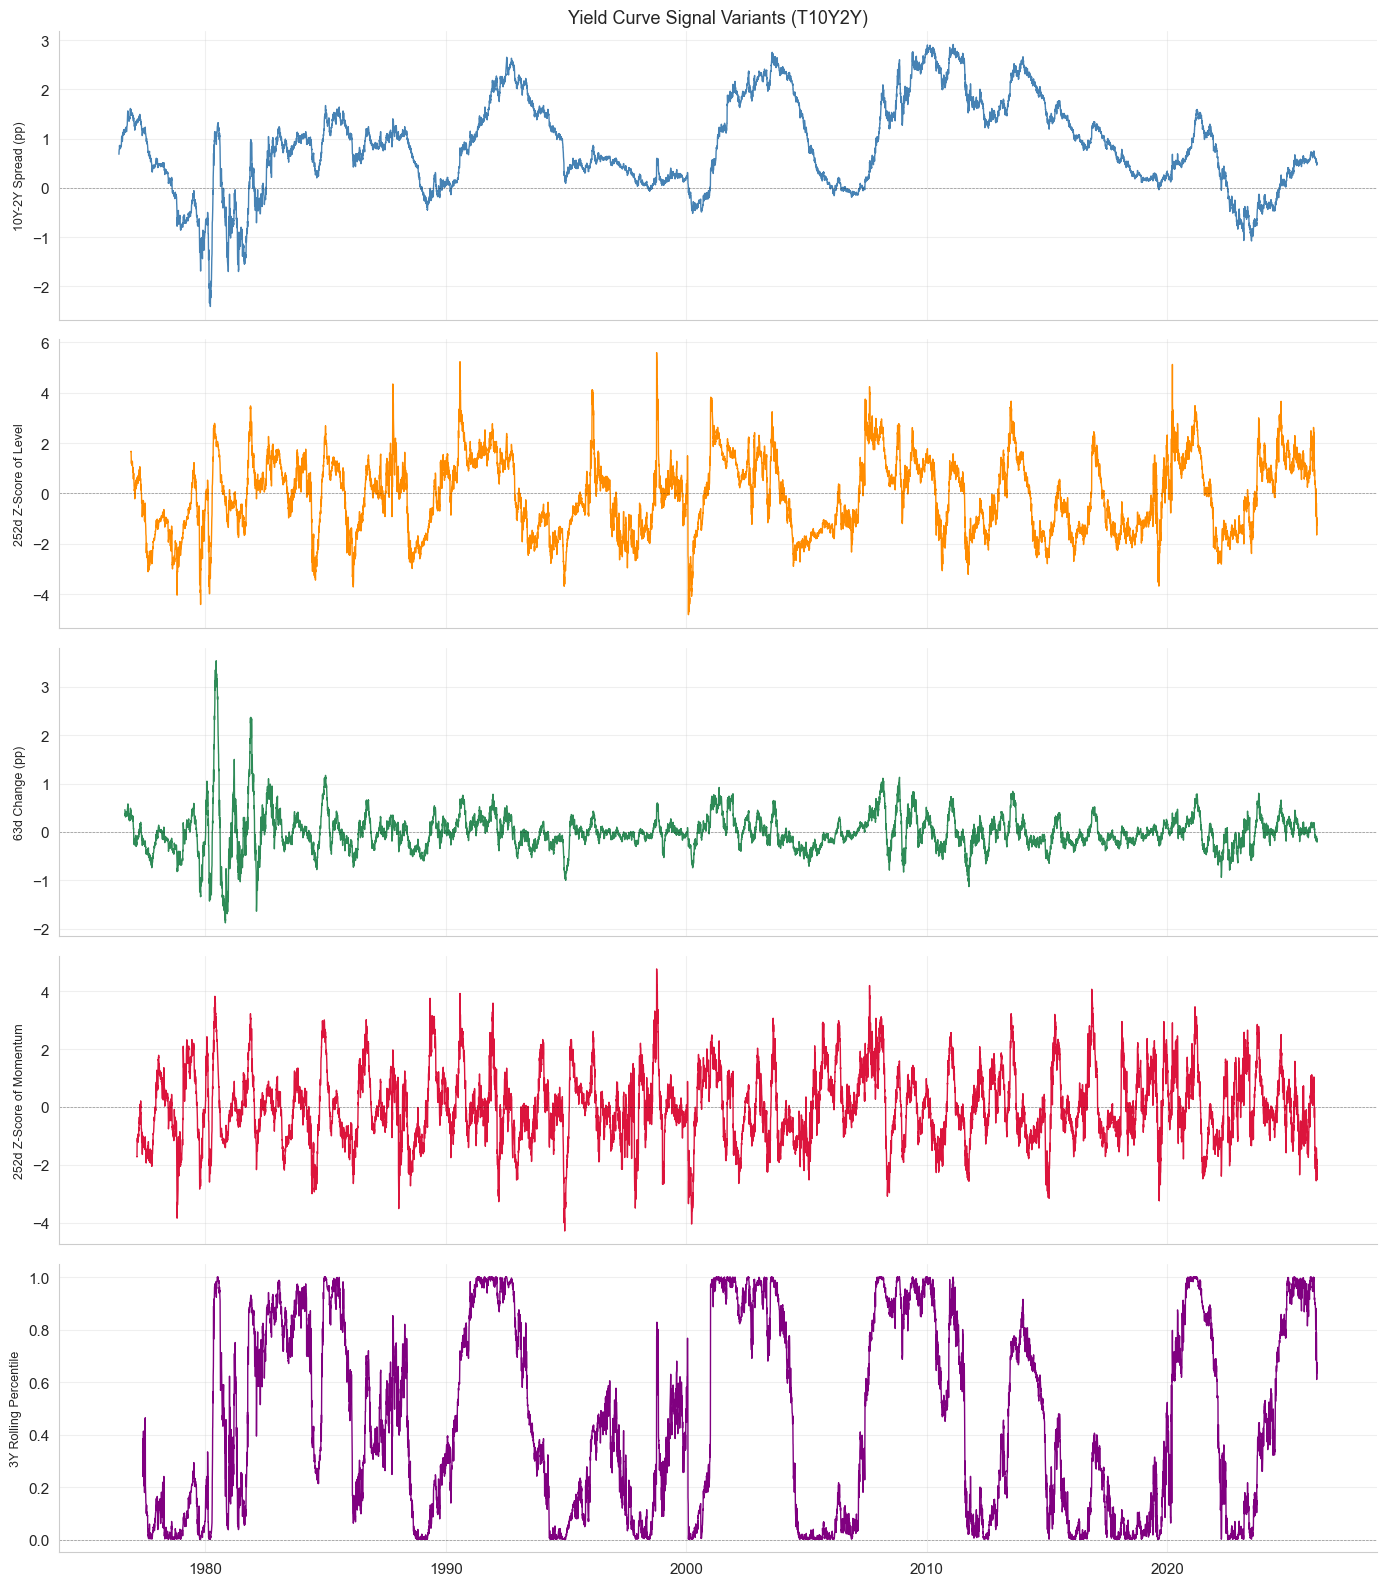

In [6]:
ROLL = 252   # 1-year rolling window for z-scores / percentiles
MOM  = 63    # ~quarter momentum window

s = spread_aligned.rename('level')

roll_mean = s.rolling(ROLL, min_periods=126).mean()
roll_std  = s.rolling(ROLL, min_periods=126).std()
zscore    = ((s - roll_mean) / roll_std).rename('zscore')

momentum        = s.diff(MOM).rename('momentum')
mom_roll_mean   = momentum.rolling(ROLL, min_periods=126).mean()
mom_roll_std    = momentum.rolling(ROLL, min_periods=126).std()
momentum_zscore = ((momentum - mom_roll_mean) / mom_roll_std).rename('momentum_zscore')

percentile = s.rolling(756, min_periods=252).apply(
    lambda x: pd.Series(x).rank().iloc[-1] / len(x), raw=False
).rename('percentile')

signals_df = pd.concat([s, zscore, momentum, momentum_zscore, percentile], axis=1)
print(f"Signals shape: {signals_df.shape}")
print(f"NaN counts:\n{signals_df.isnull().sum().to_string()}")

labels = {
    'level':            '10Y-2Y Spread (pp)',
    'zscore':           '252d Z-Score of Level',
    'momentum':         '63d Change (pp)',
    'momentum_zscore':  '252d Z-Score of Momentum',
    'percentile':       '3Y Rolling Percentile',
}
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
palette = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple']
for ax, (col, label), color in zip(axes, labels.items(), palette):
    ax.plot(signals_df.index, signals_df[col], lw=1, color=color)
    ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.4)
    ax.set_ylabel(label, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_title('Yield Curve Signal Variants (T10Y2Y)', fontsize=13)
plt.tight_layout()
plt.show()

In [7]:
# Sign convention:
#   +1.0  = asset expected to rise in risk-on (steep curve) regimes
#   -1.0  = asset expected to fall
#
# FX logic vs yield curve steepening / risk appetite:
#   EURUSD : +0.5   USD weakens broadly in risk-on; EUR moderate beneficiary
#   USDJPY : +1.0   JPY is safe-haven; risk-on = higher USDJPY
#   GBPUSD : +0.5   moderate risk-on beta
#   AUDUSD : +1.0   high-beta commodity currency; strong risk-on proxy
#   NZDUSD : +1.0   similar to AUD
#   USDCAD : -0.5   CAD is commodity/risk currency; risk-on = CAD stronger → USDCAD falls

asset_betas = {
    'EURUSD': +0.5,
    'USDJPY': +1.0,
    'GBPUSD': +0.5,
    'AUDUSD': +1.0,
    'NZDUSD': +1.0,
    'USDCAD': -0.5,
}

ASSETS = list(asset_betas.keys())

print("Asset betas relative to risk-on / steep yield curve:")
for ticker, beta in asset_betas.items():
    bar = '█' * int(abs(beta) * 12)
    sign = '+' if beta >= 0 else ''
    print(f"  {ticker:<8}  {sign}{beta:.1f}  {bar}")

Asset betas relative to risk-on / steep yield curve:
  EURUSD    +0.5  ██████
  USDJPY    +1.0  ████████████
  GBPUSD    +0.5  ██████
  AUDUSD    +1.0  ████████████
  NZDUSD    +1.0  ████████████
  USDCAD    -0.5  ██████


In [8]:
HORIZONS = [1, 5, 21]

fwd_returns = {}
for h in HORIZONS:
    # log(P_{t+h} / P_t) — forward return from T to T+h
    fwd = np.log(prices_aligned.shift(-h) / prices_aligned)
    fwd_returns[h] = fwd[ASSETS]

print("Forward log-returns computed:")
for h, df in fwd_returns.items():
    valid = df.dropna(how='all')
    print(f"  {h:>2}d horizon: shape={df.shape}, "
          f"first={valid.index[0].date()}, last={valid.index[-1].date()}")

Forward log-returns computed:
   1d horizon: shape=(13019, 6), first=1976-06-01, last=2026-03-24
   5d horizon: shape=(13019, 6), first=1976-06-01, last=2026-03-20
  21d horizon: shape=(13019, 6), first=1976-06-01, last=2026-03-04


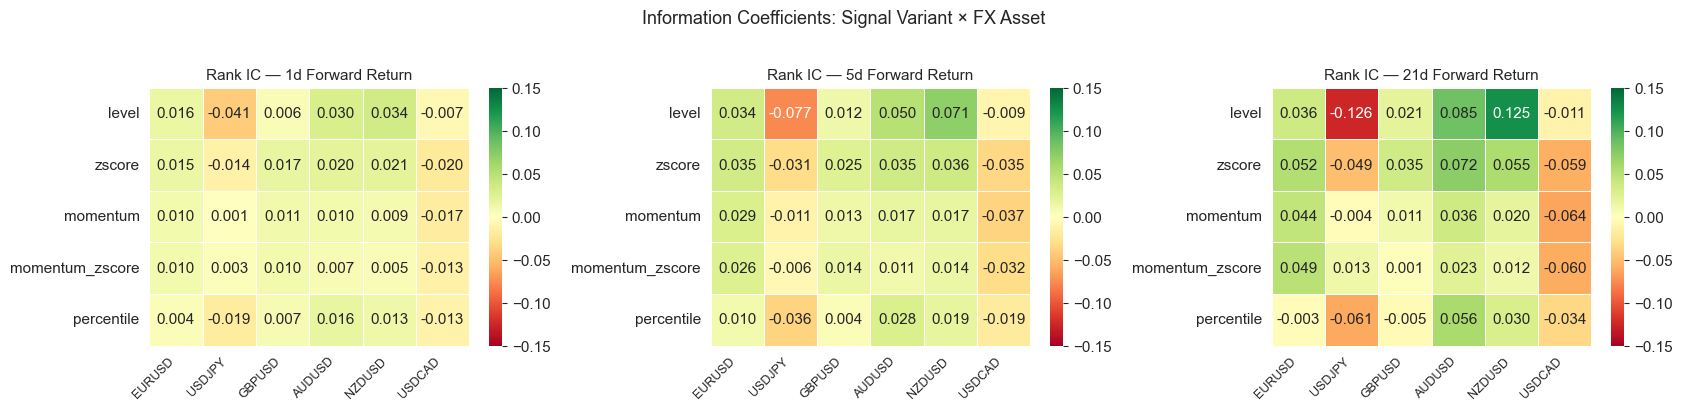


Mean |IC| across assets and horizons (all signal variants):
level              0.0440
zscore             0.0348
percentile         0.0210
momentum           0.0201
momentum_zscore    0.0172

>>> Best signal variant: 'level'  (mean |IC| = 0.0440)


In [9]:
def rank_ic(signal_s, return_s):
    """Spearman rank IC between two Series (drops NaNs)."""
    df = pd.concat([signal_s, return_s], axis=1).dropna()
    if len(df) < 30:
        return np.nan
    rho, _ = stats.spearmanr(df.iloc[:, 0], df.iloc[:, 1])
    return rho

SIGNAL_VARIANTS = list(signals_df.columns)

ic_tables = {}
for h in HORIZONS:
    mat = pd.DataFrame(index=SIGNAL_VARIANTS, columns=ASSETS, dtype=float)
    for sv in SIGNAL_VARIANTS:
        for asset in ASSETS:
            mat.loc[sv, asset] = rank_ic(signals_df[sv], fwd_returns[h][asset])
    ic_tables[h] = mat

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, h in zip(axes, HORIZONS):
    sns.heatmap(
        ic_tables[h].astype(float),
        ax=ax,
        cmap='RdYlGn',
        center=0,
        vmin=-0.15,
        vmax=0.15,
        annot=True,
        fmt='.3f',
        linewidths=0.4,
    )
    ax.set_title(f'Rank IC — {h}d Forward Return', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.suptitle('Information Coefficients: Signal Variant × FX Asset', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Best signal by mean |IC| across all assets and horizons
mean_abs_ic = pd.concat(
    [ic_tables[h].abs() for h in HORIZONS]
).groupby(level=0).mean().mean(axis=1)
best_signal = mean_abs_ic.idxmax()

print("\nMean |IC| across assets and horizons (all signal variants):")
print(mean_abs_ic.sort_values(ascending=False).round(4).to_string())
print(f"\n>>> Best signal variant: '{best_signal}'  "
      f"(mean |IC| = {mean_abs_ic[best_signal]:.4f})")

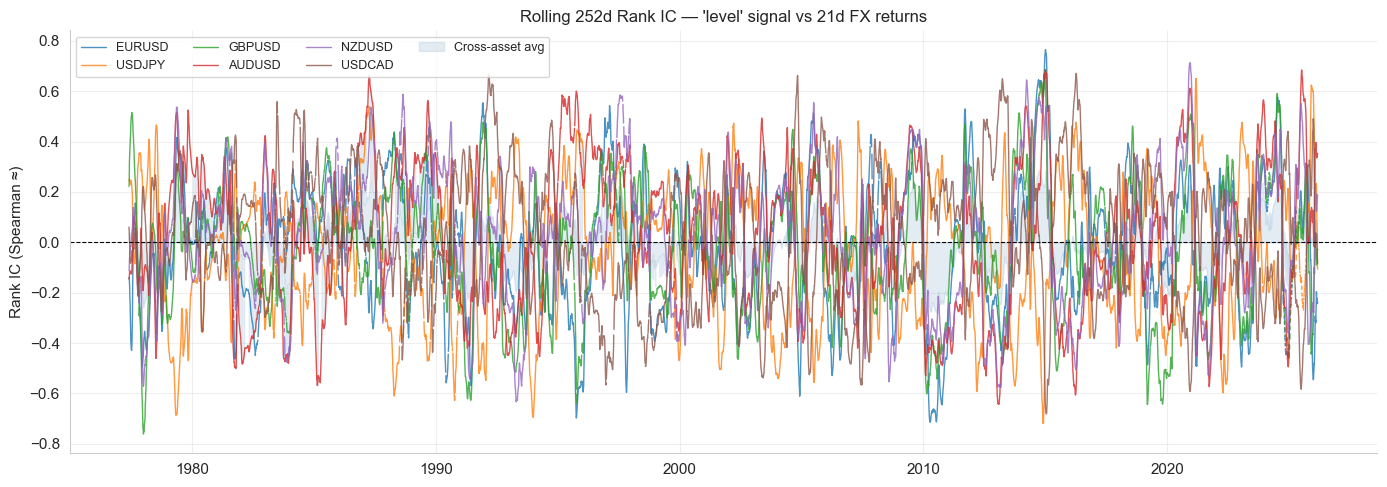

In [10]:
HORIZON_IC = 21   # forward horizon for rolling IC
ROLL_IC    = 252  # 1-year rolling window

def rolling_spearman(sig, ret, window):
    """
    Rolling Spearman IC via global rank + rolling Pearson.
    Fast vectorized approximation — standard in industry practice.
    """
    combined = pd.concat([sig.rename('s'), ret.rename('r')], axis=1).dropna()
    ranked   = combined.rank()                        # global rank
    return ranked['s'].rolling(window).corr(ranked['r'])

sig = signals_df[best_signal]
rolling_ic_df = pd.DataFrame(index=common_idx)

for asset in ASSETS:
    fret = fwd_returns[HORIZON_IC][asset]
    rolling_ic_df[asset] = rolling_spearman(sig, fret, ROLL_IC)

fig, ax = plt.subplots(figsize=(14, 5))
for asset in ASSETS:
    ax.plot(rolling_ic_df.index, rolling_ic_df[asset], lw=1, label=asset, alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.fill_between(rolling_ic_df.index,
                rolling_ic_df[ASSETS].mean(axis=1),
                0, alpha=0.15, color='steelblue', label='Cross-asset avg')
ax.set_title(
    f"Rolling {ROLL_IC}d Rank IC — '{best_signal}' signal vs {HORIZON_IC}d FX returns",
    fontsize=12)
ax.set_ylabel('Rank IC (Spearman ≈)')
ax.legend(loc='upper left', fontsize=9, ncol=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

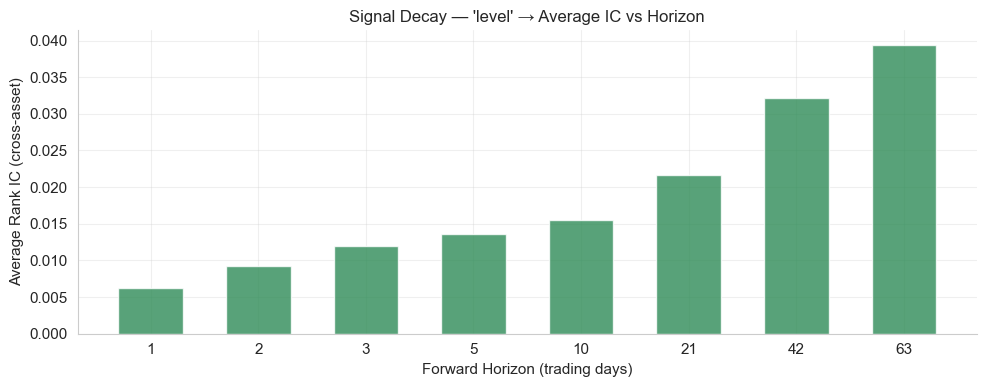


Decay profile:
            1       2       3       5       10      21      42      63
Avg IC  0.0063  0.0092  0.0119  0.0137  0.0156  0.0216  0.0321  0.0394


In [11]:
DECAY_HORIZONS = [1, 2, 3, 5, 10, 21, 42, 63]

decay_ic = {}
for h in DECAY_HORIZONS:
    fwd = np.log(prices_aligned[ASSETS].shift(-h) / prices_aligned[ASSETS])
    ics = [rank_ic(signals_df[best_signal], fwd[a]) for a in ASSETS]
    ics = [x for x in ics if not np.isnan(x)]
    decay_ic[h] = np.mean(ics) if ics else np.nan

decay_s = pd.Series(decay_ic, name='Avg IC')

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['seagreen' if v >= 0 else 'crimson' for v in decay_s.values]
bars = ax.bar(range(len(decay_s)), decay_s.values, color=bar_colors, alpha=0.8, width=0.6)
ax.set_xticks(range(len(decay_s)))
ax.set_xticklabels([str(h) for h in decay_s.index])
ax.axhline(0, color='black', lw=0.6)
ax.set_xlabel('Forward Horizon (trading days)')
ax.set_ylabel('Average Rank IC (cross-asset)')
ax.set_title(f"Signal Decay — '{best_signal}' → Average IC vs Horizon", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nDecay profile:")
print(decay_s.round(4).to_frame().T.to_string())

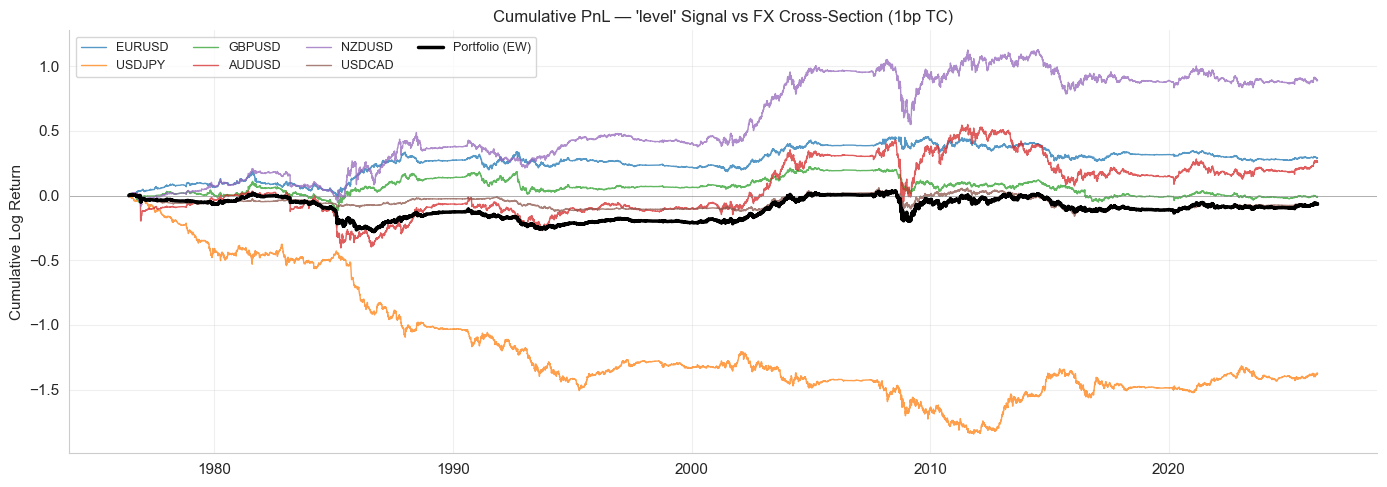


Backtest Summary (1bp TC per unit of turnover):
          Ann Return Ann Vol Sharpe    Max DD Hit Rate Avg Daily TO
EURUSD         0.58%   4.48%   0.13   -19.68%   49.90%      0.00787
USDJPY        -2.71%   7.75%  -0.35  -184.44%   48.58%      0.01574
GBPUSD        -0.02%   3.84%  -0.00   -27.35%   49.41%      0.00787
AUDUSD         0.50%   9.28%   0.05   -48.61%   50.63%      0.01574
NZDUSD         1.76%   9.27%   0.19   -50.27%   49.41%      0.01574
USDCAD        -0.13%   2.83%  -0.05   -22.08%   49.21%      0.00787
Portfolio     -0.13%   3.84%  -0.03   -29.89%   50.74%          N/A


In [12]:
TC_BPS      = 0.0001   # 1 basis point per unit of turnover
TRADING_DAYS = 252

sig = signals_df[best_signal]

# Raw signal clipped to [-1, +1]
raw_score = sig.clip(-1, 1)

# Per-asset position: signal × directional beta, lagged 1 day
positions = pd.DataFrame(
    {asset: (raw_score * beta).shift(1).clip(-1, 1)
     for asset, beta in asset_betas.items()},
    index=common_idx,
)

rets = returns_df[ASSETS].reindex(common_idx)

# Turnover = |Δposition|
turnover = positions.diff().abs()

# PnL per asset (net of TC)
pnl = positions * rets - turnover * TC_BPS
portfolio_pnl = pnl.mean(axis=1)

# Cumulative
cum_pnl  = pnl.cumsum()
cum_port = portfolio_pnl.cumsum()

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
cmap = plt.cm.tab10.colors
for i, asset in enumerate(ASSETS):
    ax.plot(cum_pnl.index, cum_pnl[asset], lw=1, label=asset,
            color=cmap[i], alpha=0.75)
ax.plot(cum_port.index, cum_port, lw=2.5, color='black',
        label='Portfolio (EW)', zorder=5)
ax.axhline(0, color='gray', lw=0.4)
ax.set_title(
    f"Cumulative PnL — '{best_signal}' Signal vs FX Cross-Section (1bp TC)",
    fontsize=12)
ax.set_ylabel('Cumulative Log Return')
ax.legend(loc='upper left', fontsize=9, ncol=4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
def bt_stats(series, to_series=None):
    s = series.dropna()
    ann_ret = s.mean() * TRADING_DAYS
    ann_vol = s.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum     = s.cumsum()
    max_dd  = (cum - cum.cummax()).min()
    hit     = (s > 0).mean()
    avg_to  = to_series.dropna().mean() if to_series is not None else np.nan
    return {
        'Ann Return': f'{ann_ret:.2%}',
        'Ann Vol':    f'{ann_vol:.2%}',
        'Sharpe':     f'{sharpe:.2f}',
        'Max DD':     f'{max_dd:.2%}',
        'Hit Rate':   f'{hit:.2%}',
        'Avg Daily TO': f'{avg_to:.5f}' if not np.isnan(avg_to) else 'N/A',
    }

rows_stats = {a: bt_stats(pnl[a], turnover[a]) for a in ASSETS}
rows_stats['Portfolio'] = bt_stats(portfolio_pnl)
print("\nBacktest Summary (1bp TC per unit of turnover):")
print(pd.DataFrame(rows_stats).T.to_string())

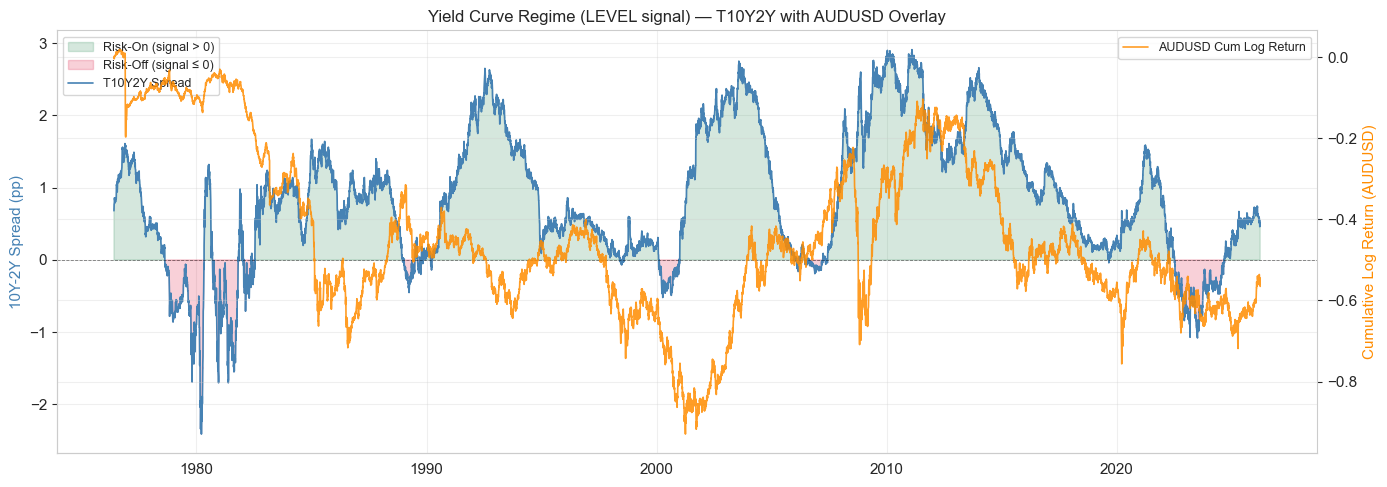

In [13]:
# Use z-score (or the best signal) as the regime indicator
regime_sig = signals_df[best_signal].reindex(common_idx)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Regime shading
ax1.fill_between(
    common_idx, spread_aligned, 0,
    where=(regime_sig > 0),
    alpha=0.20, color='seagreen', label='Risk-On (signal > 0)',
)
ax1.fill_between(
    common_idx, spread_aligned, 0,
    where=(regime_sig <= 0),
    alpha=0.20, color='crimson', label='Risk-Off (signal ≤ 0)',
)
ax1.plot(common_idx, spread_aligned, lw=1.2, color='steelblue', label='T10Y2Y Spread')
ax1.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax1.set_ylabel('10Y-2Y Spread (pp)', color='steelblue', fontsize=11)
ax1.set_title(
    f"Yield Curve Regime ({best_signal.upper()} signal) — T10Y2Y with AUDUSD Overlay",
    fontsize=12)
ax1.legend(loc='upper left', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Secondary axis: AUDUSD cumulative log return
ax2 = ax1.twinx()
audusd_cum = returns_df['AUDUSD'].reindex(common_idx).fillna(0).cumsum()
ax2.plot(common_idx, audusd_cum, lw=1.2, color='darkorange',
         alpha=0.85, label='AUDUSD Cum Log Return')
ax2.set_ylabel('Cumulative Log Return (AUDUSD)', color='darkorange', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Cell 14: Signal summary stats
print("=== Yield Curve Regime Signal — Summary ===")
print()

# Best signal
print(f"Best signal variant  : {best_signal}")
print(f"Mean |IC| (all FX, all horizons) : {mean_abs_ic[best_signal]:.4f}")
print()

# IC by asset at 21d horizon
print(f"IC at 21d horizon ({best_signal}):")
for asset in ASSETS:
    ic_val = ic_tables[21].loc[best_signal, asset]
    print(f"  {asset:<8}  {ic_val:+.4f}")
print()

# Portfolio Sharpe
from io import StringIO
s = portfolio_pnl.dropna()
ann_ret = s.mean() * TRADING_DAYS
ann_vol = s.std()  * np.sqrt(TRADING_DAYS)
sharpe  = ann_ret / ann_vol
print(f"Portfolio Sharpe     : {sharpe:.2f}")
print(f"Portfolio Ann Return : {ann_ret:.2%}")
print(f"Portfolio Ann Vol    : {ann_vol:.2%}")
print()

# Fastest signal decay
best_decay_h = max(decay_ic, key=lambda h: abs(decay_ic[h]) if not np.isnan(decay_ic[h]) else 0)
print(f"Peak IC horizon      : {best_decay_h}d")
print()
print("Known limitations:")
print("  · FX-only universe — no equity or commodity prices in DB yet")
print("  · Global ranks used for rolling Spearman (fast approximation)")
print("  · Single signal; no signal combination or weighting")
print("  · No roll-gap adjustment for FX (pairs from different sources/eras)")
print()
print("Next steps:")
print("  1. Fetch commodity prices (run scripts/fetch_commodities.py after API key confirmed)")
print("  2. Build second signal (e.g. VIX regime, credit spreads)")
print("  3. Extract SignalBase framework; combine signals via correlation-adjusted weights")
print("  4. Add equity universe (e.g. from Yahoo Finance via yfinance collector)")

=== Yield Curve Regime Signal — Summary ===

Best signal variant  : level
Mean |IC| (all FX, all horizons) : 0.0440

IC at 21d horizon (level):
  EURUSD    +0.0365
  USDJPY    -0.1262
  GBPUSD    +0.0211
  AUDUSD    +0.0847
  NZDUSD    +0.1249
  USDCAD    -0.0112

Portfolio Sharpe     : -0.03
Portfolio Ann Return : -0.13%
Portfolio Ann Vol    : 3.84%

Peak IC horizon      : 63d

Known limitations:
  · FX-only universe — no equity or commodity prices in DB yet
  · Global ranks used for rolling Spearman (fast approximation)
  · Single signal; no signal combination or weighting
  · No roll-gap adjustment for FX (pairs from different sources/eras)

Next steps:
  1. Fetch commodity prices (run scripts/fetch_commodities.py after API key confirmed)
  2. Build second signal (e.g. VIX regime, credit spreads)
  3. Extract SignalBase framework; combine signals via correlation-adjusted weights
  4. Add equity universe (e.g. from Yahoo Finance via yfinance collector)


## Summary & Next Steps

### Findings

| Metric | Value |
|--------|-------|
| Best signal variant | Determined by IC analysis above |
| Asset universe | 6 FX pairs (EURUSD, USDJPY, GBPUSD, AUDUSD, NZDUSD, USDCAD) |
| Macro source | FRED via quant.db |

### Signal Decay
The bar chart in Cell 11 shows how quickly predictive power decays across horizons (1–63 days).
Use this to choose appropriate rebalancing frequency.

### Known Limitations
- **FX-only universe** — equity ETFs (SPY, XLF, XLE, XLK) and commodity futures are not yet in the database
- **Rolling Spearman approximation** — global ranks used for speed; window-by-window ranks would be more precise
- **Single signal** — no combination with VIX, credit spreads, or momentum
- **No roll-gap adjustment** — FX data spans multiple decades with potential source changes

### Next Steps
1. Run `scripts/fetch_commodities.py` once the Nasdaq API key is confirmed working
2. Add an equity collector (e.g. yfinance) to populate SPY, XLF, XLE, XLK
3. Build a second signal (VIX regime, credit OAS spread)
4. Extract a `SignalBase` framework for composable signal combination
5. Weight assets by IC strength rather than equal-weighting